<h1 style="background-color: #0d2363; color: white; padding: 15px; border-radius: 5px; margin-top: 0;">Student Club EDA </h1>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Introduction & Objectives</b>
<br>The main goal for this EDA is to provide detailed information about the performance of a Hungaryan Student Association <br>
</div>

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">1. Import all the neccessary libraries for the project</h3>

In [81]:
import warnings
from IPython.core.pylabtools import figsize
from pandas.core.methods.selectn import DataFrame
from scipy.cluster.hierarchy import average
from unicodedata import category
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv("Kreditnyilvantartas_renamed.csv")
df.shape

(151, 24)

In [82]:
def evaluate_status(row):

    col_crit = 'Kreditkritérium teljesülése'
    col_prof = '9 kötelező szakmai kredit bevezetése esetén kiesők'

    val_crit = str(row[col_crit]).lower()
    val_prof = str(row[col_prof]).lower()

    if ('nem teljesítette' in val_crit) or ('kiesett' in val_crit) or \
       ('kiesne' in val_prof) or ('kiesett' in val_prof):
        return 0
    else:
         return 1

df["Final_Retention"] = df.apply(evaluate_status, axis=1)

columns_to_drop = [
    'Méltányosság minimális kreditszerzés vagy Pacioli Képzés alól',
    'Unnamed: 21',
    'megjegyzés',
    'Egyetemi évfolyam (évfolyam)',
    'Tagszervezeti evfolyam'
]

# Drop the columns (with errors='ignore' to prevent KeyError on rerun)
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

credit_columns = [
    'Kötelezően választható szakmai kurzusok',
    'Szabadon választható szakmai kurzusok',
    'Részvétel a Diákszervezeti Taggyűlésen',
    'Demonstrátori tevékenység',
    'Oktatási tevékenység, vizsgafelkészítők tartása',
    'Tagszervezeti vezetőségi tagság/Egyesületben végzett munka',
    'Tagszervezeti elnökségi kreditek',
    'Mentorprogramban való részvétel',
    'Munkavállalásért járó kredit',
    'Egyesületi vezetőségi kredit'
]

for col in credit_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(",", ".")

    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df["Overall_Credit"] = df[credit_columns].sum(axis=1)

df['Tanulmányi átlag'] = df['Tanulmányi átlag'].astype(str).str.replace(",", ".")
df['Tanulmányi átlag'] = pd.to_numeric(df['Tanulmányi átlag'], errors='coerce')

average_grade = df["Tanulmányi átlag"].mean()
df['Tanulmányi átlag'] = df['Tanulmányi átlag'].fillna(average_grade)


df["Van_Versenyeredmeny"] = df['TDK, OTDK, versenyeredmények'].apply(lambda x:
                                                                              0 if str(x).strip() in  ['0', '0.0', 'nan', 'nincs']
                                                                              else 1)


In [83]:
df.iloc[:10]

,Ssz.,Név,Tagszervezet,Kötelezően választható szakmai kurzusok,Szabadon választható szakmai kurzusok,Részvétel a Diákszervezeti Taggyűlésen,Demonstrátori tevékenység,Tanulmányi átlag,"Oktatási tevékenység, vizsgafelkészítők tartása","TDK, OTDK, versenyeredmények",...,Mentorprogramban való részvétel,Munkavállalásért járó kredit,Egyesületi vezetőségi kredit,"Összes kredit ""(max. 30)""",Kreditkritérium teljesülése,Kreditkritérium nem teljesülésének oka,9 kötelező szakmai kredit bevezetése esetén kiesők,Final_Retention,Overall_Credit,Van_Versenyeredmeny
0,1.0,Szabó Bence,BTE TE,5.0,8.0,1.0,0.0,3.000000,0.0,0.0,...,3.0,2.0,0.0,27.0,Teljesítve,Teljesítve,NaN,1,24.0,0
1,2.0,Farkas Péter,BVE TE,0.0,0.0,-3.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,-3.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,-3.0,0
2,3.0,Molnár Balázs,BVE KL,0.0,0.0,1.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,1.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,1.0,0
3,4.0,Szabó Éva,BVE KL,4.0,0.0,1.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,5.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,5.0,0
4,5.0,Tóth Nóra,BVE TE,0.0,0.0,1.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,1.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,1.0,0
5,6.0,Lakatos Máté,BVE KL,5.0,6.0,1.0,0.0,1.500000,0.0,0.0,...,3.0,2.0,0.0,NaN,Teljesítve,Teljesítve,NaN,1,23.0,0
6,7.0,Nagy Levente,BTE TE,5.0,6.0,1.0,0.0,1.500000,0.0,0.0,...,3.0,2.0,0.0,NaN,Teljesítve,Teljesítve,NaN,1,27.0,0
7,8.0,Kiss Péter,BVE KL,0.0,4.0,1.0,0.0,1.500000,0.0,0.0,...,0.0,2.0,0.0,NaN,Teljesítve,Teljesítve,Kiesne: Szakmai kredit < 9,0,22.0,0
8,9.0,Fekete Dóra,PTE PANE,8.0,6.0,1.0,0.0,2.376923,0.0,0.0,...,3.0,2.0,0.0,26.0,Teljesítve,Teljesítve,NaN,1,26.0,0
9,10.0,Nagy Éva,BTE TE,0.0,4.0,1.0,0.0,1.500000,0.0,0.0,...,3.0,2.0,0.0,NaN,Nem teljesítette,Kiesett: Összes kredit < 15,Kiesne: Szakmai kredit < 9,0,10.0,0


In [84]:
print(df.isna().sum())

Ssz.                                                           0
Név                                                            0
Tagszervezet                                                   0
Kötelezően választható szakmai kurzusok                        0
Szabadon választható szakmai kurzusok                          0
Részvétel a Diákszervezeti Taggyűlésen                         0
Demonstrátori tevékenység                                      0
Tanulmányi átlag                                               0
Oktatási tevékenység, vizsgafelkészítők tartása                0
TDK, OTDK, versenyeredmények                                   0
Tagszervezeti vezetőségi tagság/Egyesületben végzett munka     0
Tagszervezeti elnökségi kreditek                               0
Mentorprogramban való részvétel                                0
Munkavállalásért járó kredit                                   0
Egyesületi vezetőségi kredit                                   0
Összes kredit "(max. 30)"

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Target Variables</h3>

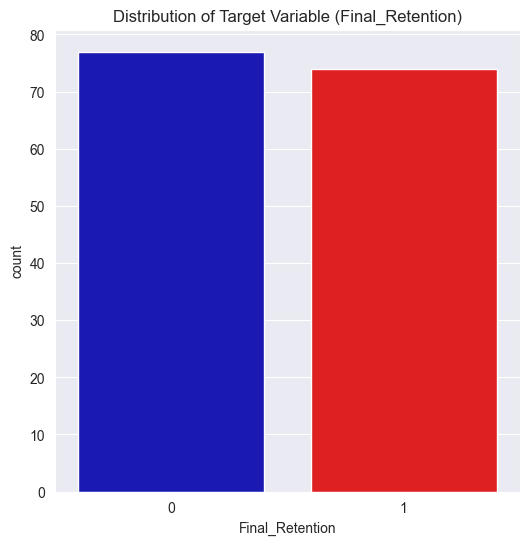

In [96]:
def target_variables(dataframe: pd.DataFrame) -> None:
    binary_palette = ["mediumblue", "red"]
    plt.figure(figsize=(6,6))
    sns.countplot(x=dataframe["Final_Retention"], palette=binary_palette)
    plt.title("Distribution of Target Variable (Final_Retention)")
    plt.show()

target_variables(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b> Under construction</b>
<br> **Under construction** <br>
</div>

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Category Vairables</h3>

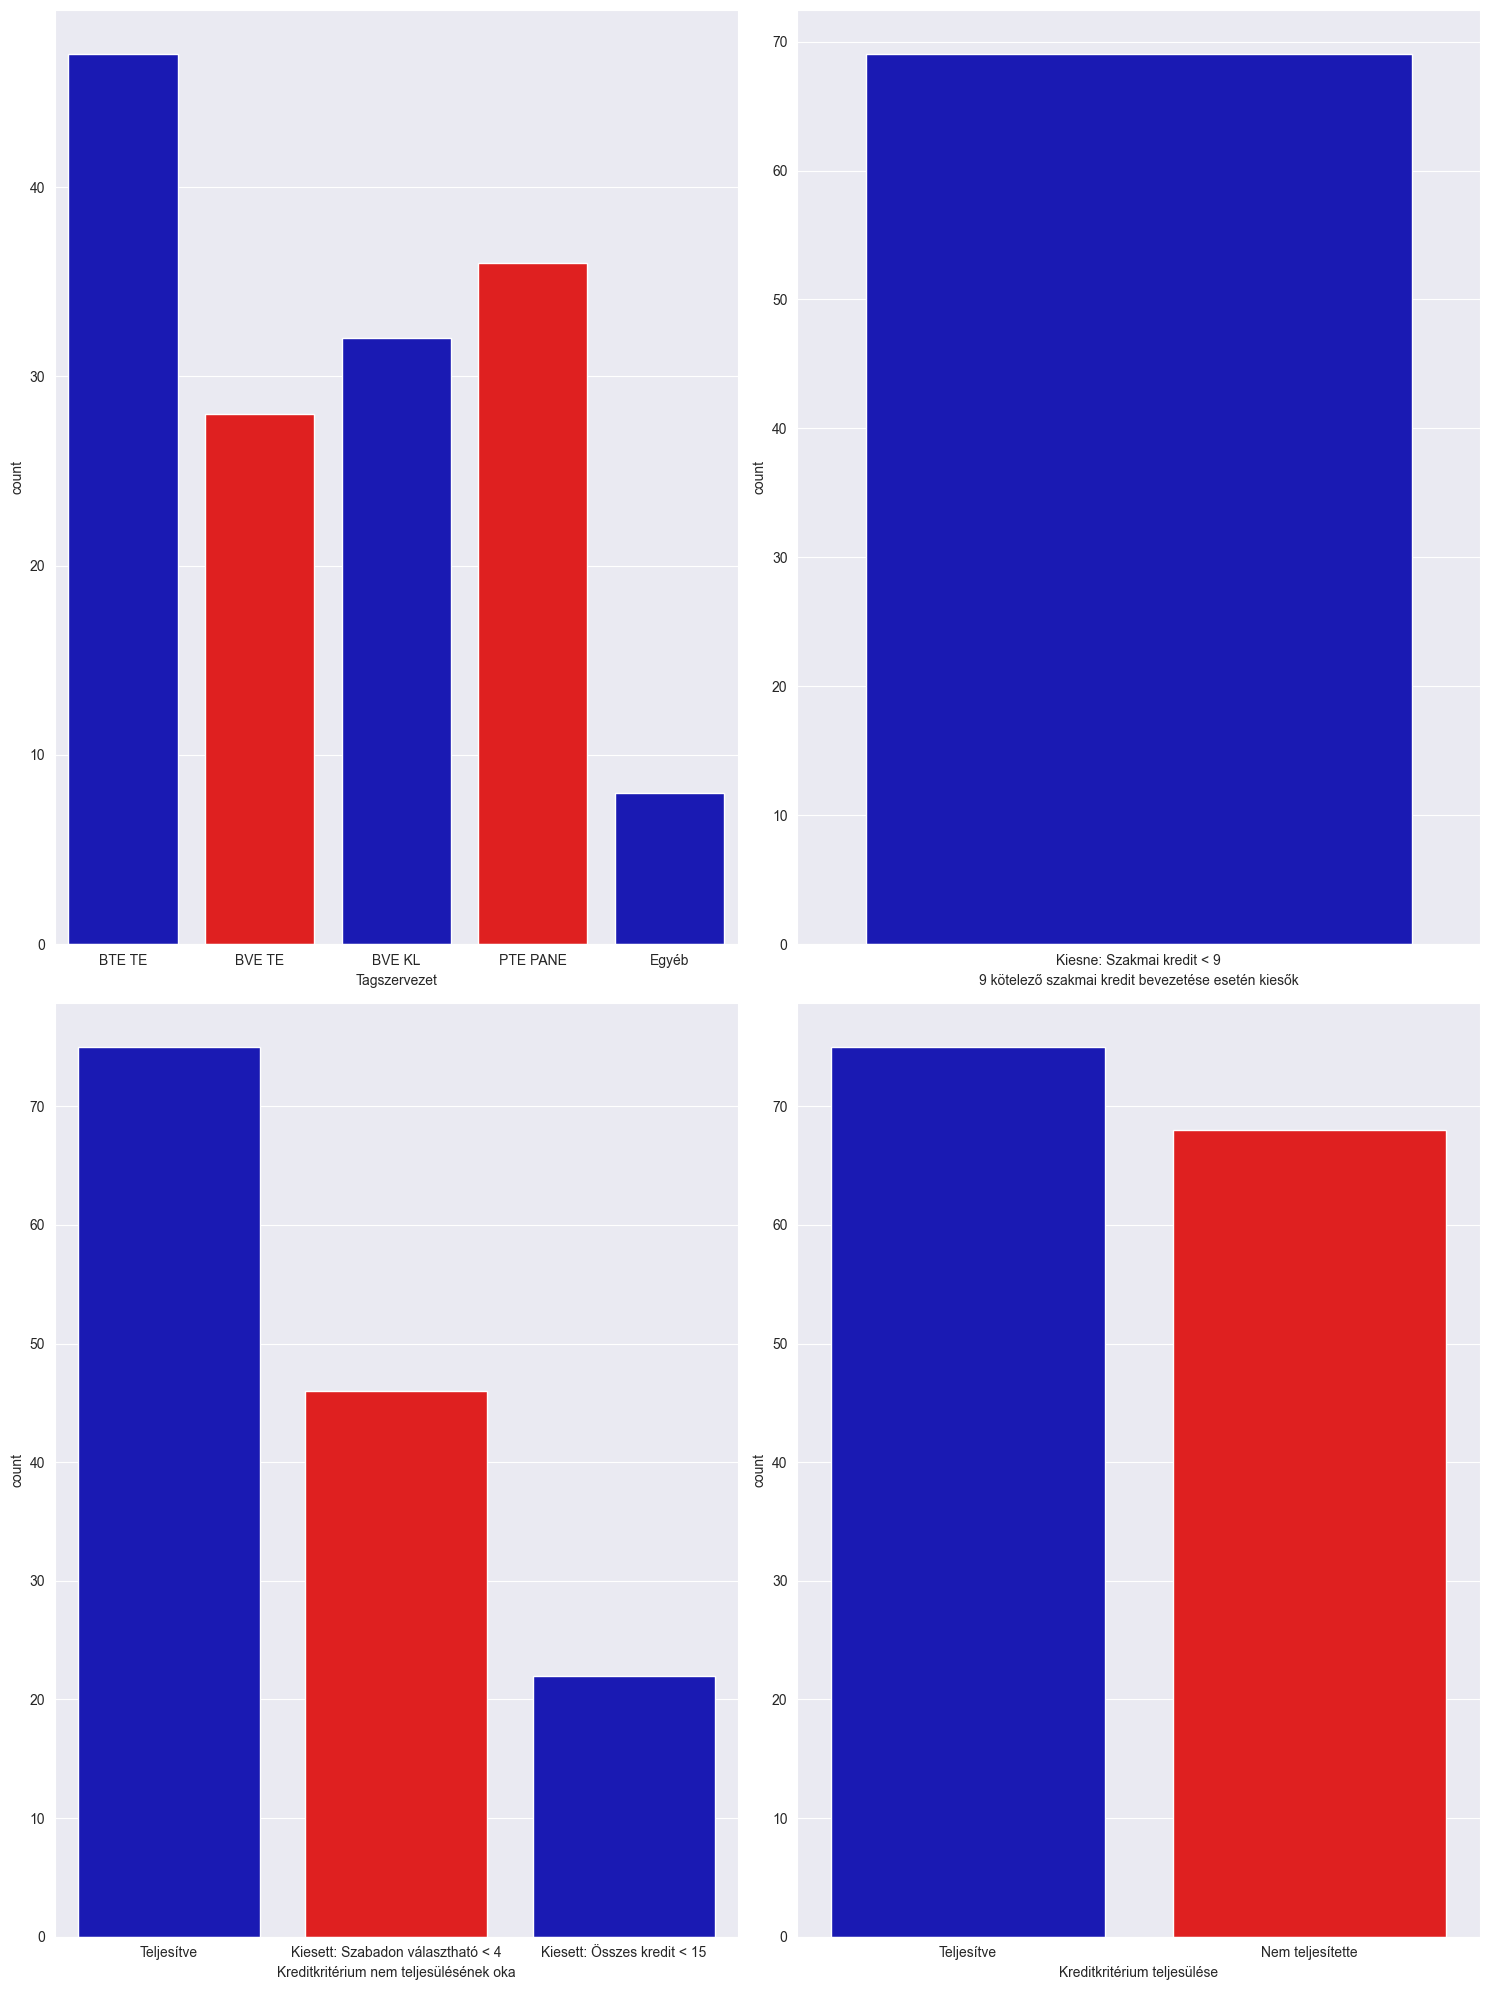

In [97]:
def category_vairables(dataframe: pd.DataFrame) -> None:

    binary_palette = ["mediumblue", "red"]


    categorical_variables = ["Tagszervezet", "9 kötelező szakmai kredit bevezetése esetén kiesők", "Kreditkritérium nem teljesülésének oka", "Kreditkritérium teljesülése"]


    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,20))

    for var, subplot in zip(categorical_variables, axes.flatten()):
        sns.countplot(x=var, data=dataframe, ax=subplot, palette=binary_palette)
        for label in subplot.get_xticklabels():
           label.set_rotation(0)


    plt.tight_layout()
    plt.show()

category_vairables(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b> Under construction</b>
<br> **Under construction** <br>
</div>

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Continous Vairables</h3>